In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# A histogram of the O3 concentrations


In [3]:
aqs = pd.read_csv('C:/Users/mayav/Desktop/GEOL415/LA_AQS_2023.csv')

In [316]:
O3_aqs = aqs[(aqs['Parameter Name']=='Ozone')&(aqs['Duration Description']=='1 HOUR')]

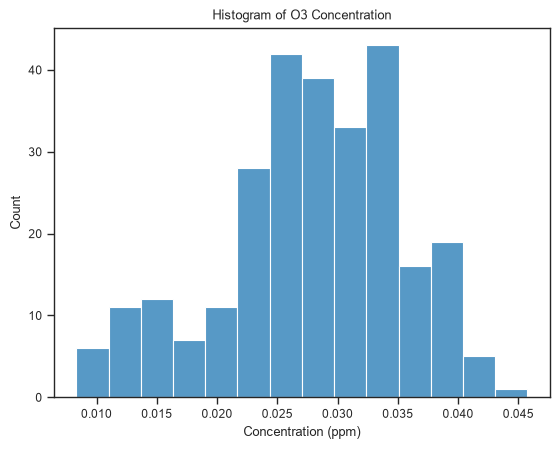

In [319]:
sns.histplot(
    data=O3_aqs, x='Arithmetic Mean')
plt.xlabel('Concentration (ppm)')
plt.title('Histogram of O3 Concentration')
plt.show()

In [6]:
# The ozone concentration is between 30-35 ppbv most of the time.

In [7]:
# A density plot of NO2 concentrations


In [8]:
NO2_aqs = aqs[(aqs['Parameter Name']=='Nitrogen dioxide (NO2)')&(aqs['Duration Description']=='1 HOUR')]

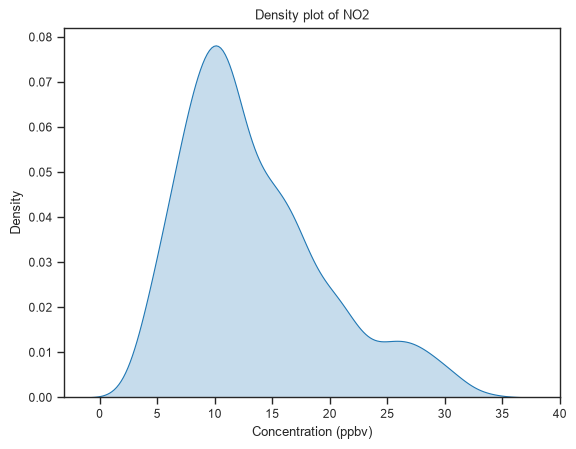

In [321]:
sns.kdeplot(
    data=NO2_aqs, x='Arithmetic Mean', fill=bool)
plt.ylabel('Density')
plt.xlabel('Concentration (ppbv)')
plt.title('Density plot of NO2')
plt.show()

In [11]:
# The concentration of NO2 is low most of the time.

In [12]:
# A scatter plot of O3 vs NO2 concentrations*


In [31]:
O3 = pd.DataFrame(data = {"O3" : (O3_aqs['Arithmetic Mean']* 1e3), 'Time' : (O3_aqs['Date (Local)'])})
NO2 = pd.DataFrame(data = {"NO2" : (NO2_aqs['Arithmetic Mean']), 'Time' : (NO2_aqs['Date (Local)'])})
O3andNO2 = O3.merge(NO2, on=['Time'])

In [32]:
O3andNO2

,O3,Time,NO2
0,31.708,2023-01-01,4.816667
1,31.708,2023-01-01,4.550000
2,31.708,2023-01-01,4.550000
3,31.708,2023-01-01,4.816667
4,15.792,2023-01-02,14.720833
...,...,...,...
1087,39.048,2023-09-29,8.614286
1088,30.042,2023-09-30,6.370833
1089,30.042,2023-09-30,6.370833
1090,30.042,2023-09-30,7.362500


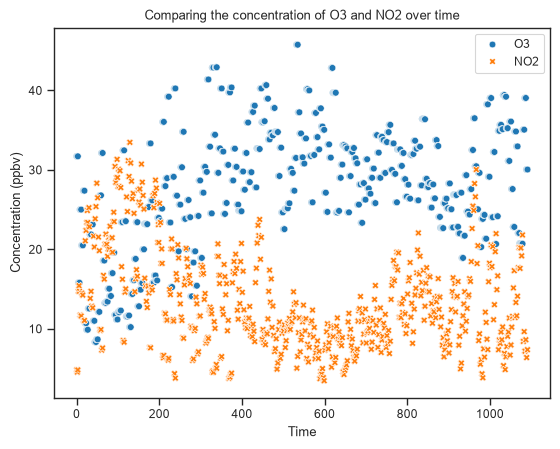

In [322]:
sns.scatterplot(
    data=(O3andNO2))
plt.ylabel('Concentration (ppbv)')
plt.xlabel('Time')
plt.title('Comparing the concentration of O3 and NO2 over time')
plt.show()

In [15]:
# Ozone concentrations tend to be higher than NO2 concentrations most of the time.

In [16]:
# A barchart of the number of days per month with O3 > 35 ppb


In [142]:
above_35 = O3_aqs[O3_aqs['Arithmetic Mean'] > .035]

In [144]:
above_35["month"]=pd.to_datetime(O3_aqs['Date (Local)']).dt.month

In [138]:
O3_above.describe()

,Is it above,Time
count,273,273
unique,2,273
top,False,2023-01-01
freq,230,1


Text(0.5, 1.0, 'Number of days in a given month where O3 concentration exceeds 35ppbv')

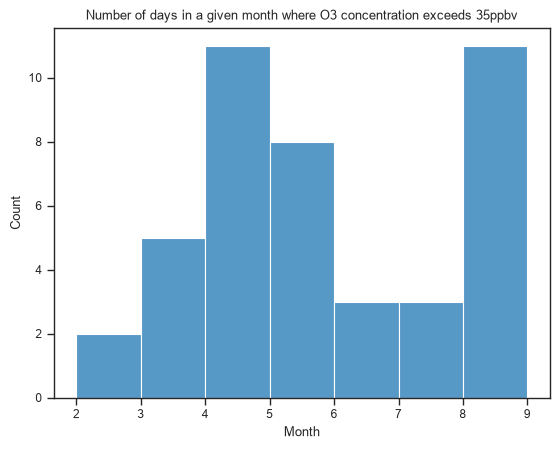

In [323]:
sns.histplot(
    data=above_35, x='month')
plt.xlabel('Month')
plt.title('Number of days in a given month where O3 concentration exceeds 35ppbv')

In [ ]:
# O3 concentration reaches high values more times in the middle and end of the year


In [153]:
# Make a scatterplot of average CO2 concentrations vs time (decimal date).

In [154]:
ml = pd.read_csv("C:/Users/mayav/Desktop/GEOL415/ManuaLoa_CO2.csv")

In [159]:
ml.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99


<Axes: title={'center': 'Average Concentration of CO2 over time in Mauna Loa'}, xlabel='Time', ylabel='Average Concentration of CO2'>

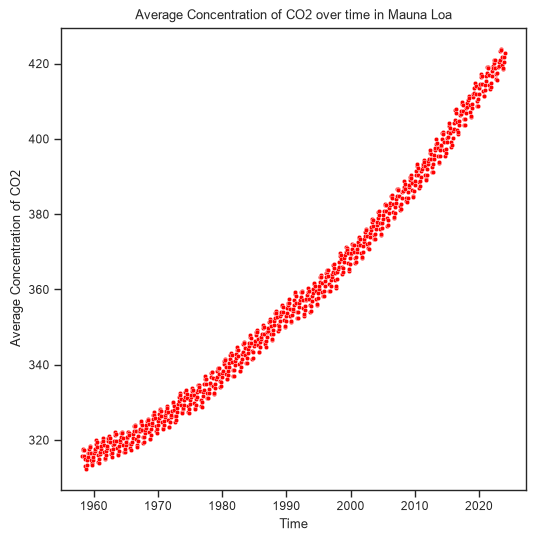

In [325]:
fig1, ax = plt.subplots(figsize=(6,6))
plt.xlabel('Time')
plt.ylabel('Average Concentration of CO2')
plt.title('Average Concentration of CO2 over time in Mauna Loa')
sns.scatterplot(
    data=ml, x='decimal date', y='average', s=10, color=("red"))

In [ ]:
# In the scatterplot we can see the seasonal shifts and expected fluxuations for CO2 concentrations in years surrounding a given point
# Mainly, though, we see that there is a clear increasing trend for CO2 concentration over time.

In [244]:
# BAD scatterplot

<Axes: title={'center': 'the relationship between these axes'}, xlabel='years from earlier to closer to now', ylabel='CO2 in the air'>

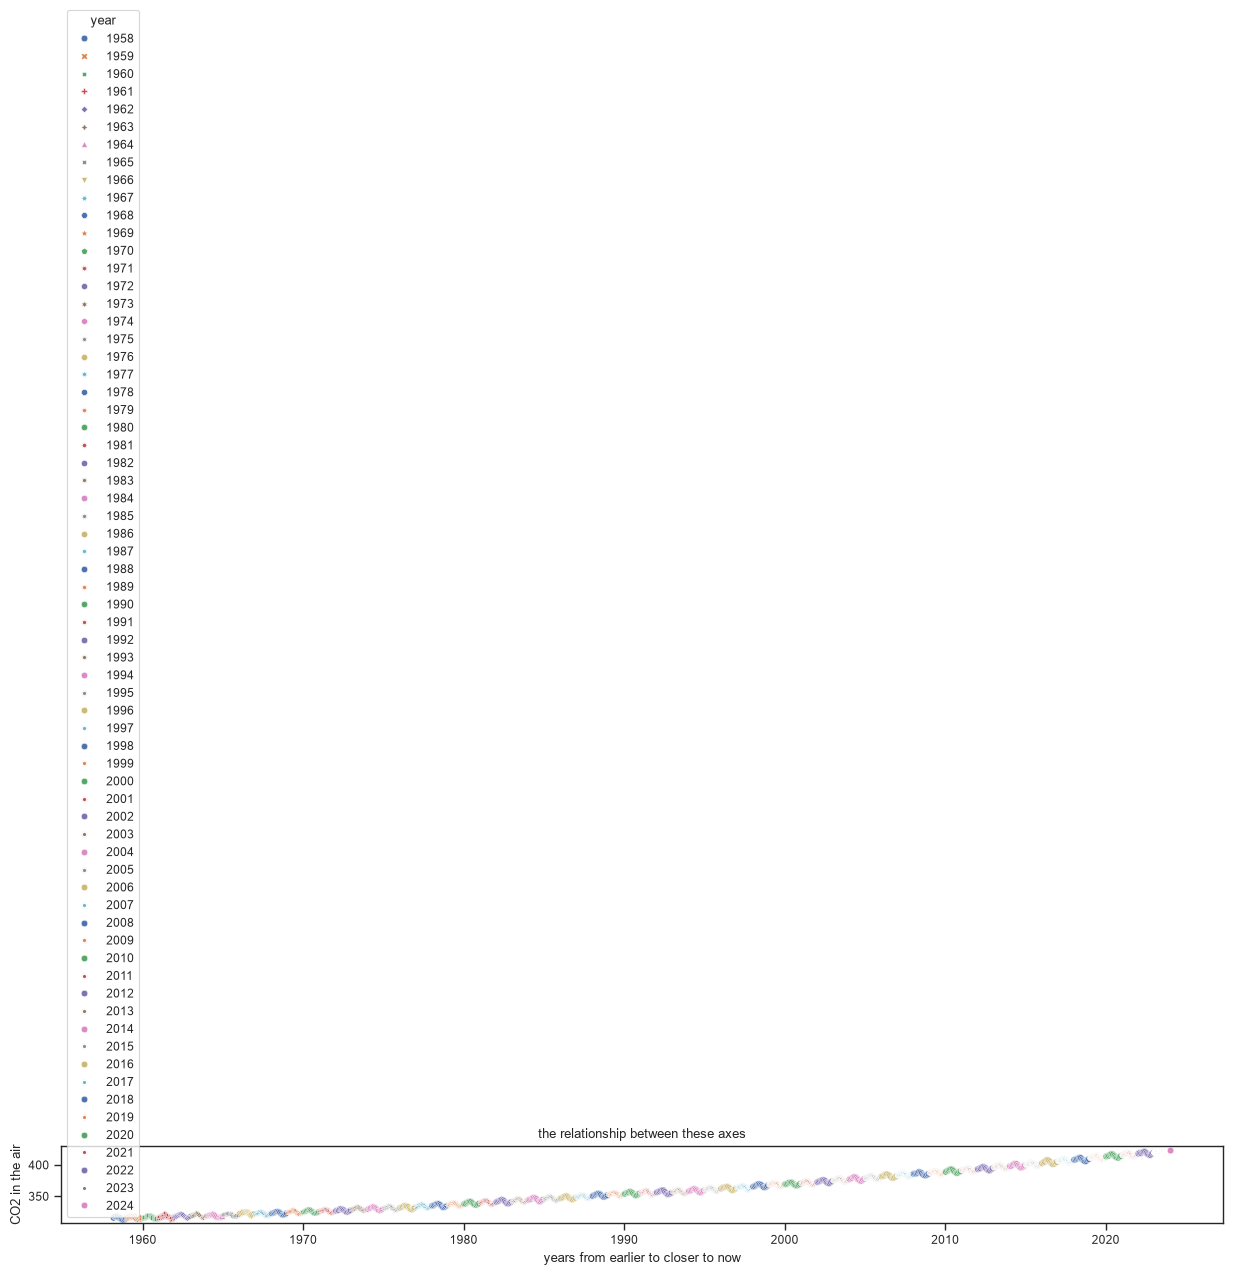

In [302]:
fig2, ax = plt.subplots(figsize=(15,1))
plt.xlabel('years from earlier to closer to now')
plt.ylabel('CO2 in the air')
plt.title('the relationship between these axes')
sns.scatterplot(
    data=ml, x='decimal date', y='average', hue=("year"), style="year", palette=("deep"), marker=("*"))